> Assignment 3 Plots

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/yvonnelee/Desktop/DSI/visualization/02_activities/assignments/university_enrolment_headcount_2024-25.csv")

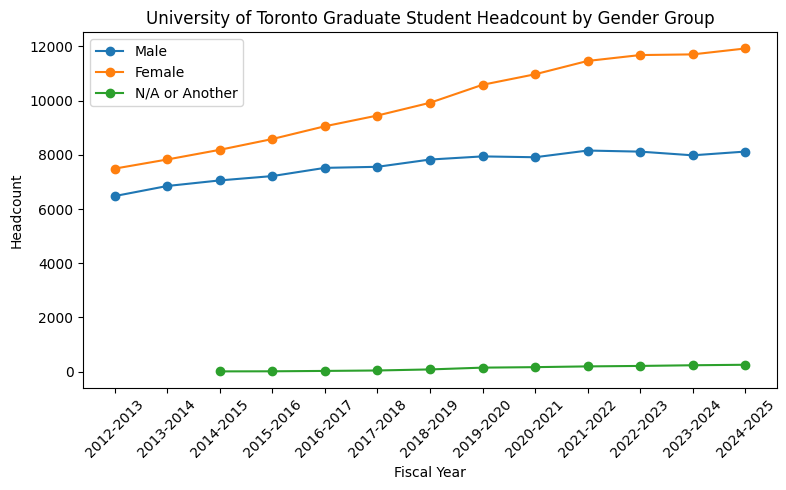

In [28]:

df = df[
    (df["Institution"] == "Toronto") &
    (df["Study Level"] == "Graduate")
].copy()

df["HEADCOUNT"] = pd.to_numeric(
    df["HEADCOUNT"].str.replace(",", ""),
    errors="coerce"
)


pivot = df.pivot(
    index="Fiscal Year",
    columns="Gender Group",
    values="HEADCOUNT"
)


plt.figure(figsize=(8, 5))
for gender in ["Male", "Female", "N/A or Another"]:
    if gender in pivot.columns:
        plt.plot(pivot.index, pivot[gender], marker="o", label=gender)

plt.title("University of Toronto Graduate Student Headcount by Gender Group")
plt.xlabel("Fiscal Year")
plt.ylabel("Headcount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

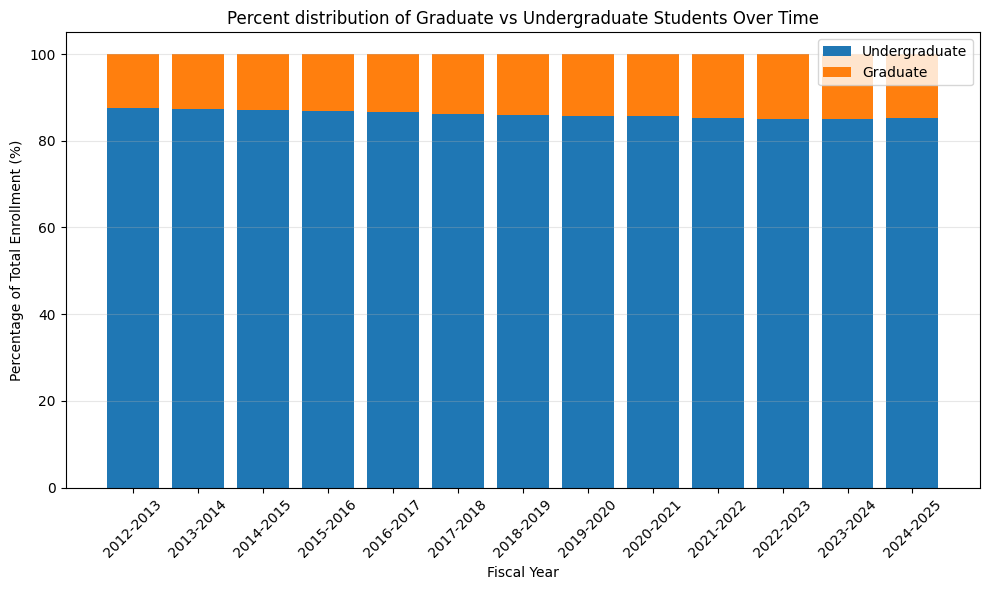

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/yvonnelee/Desktop/DSI/visualization/02_activities/assignments/university_enrolment_headcount_2024-25.csv")

# Convert HEADCOUNT to numeric
df["HEADCOUNT"] = pd.to_numeric(
    df["HEADCOUNT"].astype(str).str.replace(",", ""),
    errors="coerce"
)

# Keep only Undergraduate and Graduate rows
df = df[df["Study Level"].isin(["Undergraduate", "Graduate"])]

# Sum headcount across genders and institutions
agg = (
    df.groupby(["Fiscal Year", "Study Level"])["HEADCOUNT"]
    .sum()
    .reset_index()
)

# Reshape data
pivot = agg.pivot(
    index="Fiscal Year",
    columns="Study Level",
    values="HEADCOUNT"
).fillna(0)

# Convert to percentages (so each year sums to 100%)
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Sort by year just in case
pct = pct.sort_index()

# Plot stacked 100% bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    pct.index,
    pct["Undergraduate"],
    label="Undergraduate"
)

plt.bar(
    pct.index,
    pct["Graduate"],
    bottom=pct["Undergraduate"],
    label="Graduate"
)

plt.title("Percent distribution of Graduate vs Undergraduate Students Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Percentage of Total Enrollment (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()